In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import glob
import re

ruta_archivos = "/content/drive/MyDrive/Practica4/*.csv"
archivos = glob.glob(ruta_archivos)

ruta_salida = "/content/drive/MyDrive/Practica4/ecobici_limpio_completo.csv"
es_primer_archivo = True

columnas_a_eliminar = ['Fecha_Retiro', 'Hora_Retiro', 'Fecha_Arribo', 'Hora_Arribo']
columnas_numericas = ['Edad_Usuario', 'Ciclo_Estacion_Retiro', 'Ciclo_Estacion_Arribo', 'Bici']

for file in archivos:
    try:
        print(f"Procesando: {file}")
        df = pd.read_csv(file, low_memory=False)

        df['Genero_Usuario'] = df['Genero_Usuario'].map({'F': 0, 'M': 1}).astype('Int64')

        for col in columnas_numericas:
            if col in df.columns:
                df[col] = df[col].astype(str).str.extract(r'(\d+)')
                df[col] = df[col].astype('Int64')

        df.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')

        # Guardar en archivo limpio
        df.to_csv(ruta_salida, mode='a', header=es_primer_archivo, index=False)
        es_primer_archivo = False

        print(f"Archivo procesado")

    except Exception as e:
        print(f"Error en {file}: {e}")

Procesando: /content/drive/MyDrive/Practica4/2010-03-mar.csv
Archivo procesado
Procesando: /content/drive/MyDrive/Practica4/2010-04-abr.csv
Archivo procesado
Procesando: /content/drive/MyDrive/Practica4/2010-05-may.csv
Archivo procesado
Procesando: /content/drive/MyDrive/Practica4/2010-06-jun.csv
Archivo procesado
Procesando: /content/drive/MyDrive/Practica4/2010-07-jul.csv
Archivo procesado
Procesando: /content/drive/MyDrive/Practica4/2010-08-ago.csv
Archivo procesado
Procesando: /content/drive/MyDrive/Practica4/2010-09-sep.csv
Archivo procesado
Procesando: /content/drive/MyDrive/Practica4/2010-10-oct.csv
Archivo procesado
Procesando: /content/drive/MyDrive/Practica4/2010-11-nov.csv
Archivo procesado
Procesando: /content/drive/MyDrive/Practica4/2010-12-dic.csv
Archivo procesado
Procesando: /content/drive/MyDrive/Practica4/2011-01-ene.csv
Archivo procesado
Procesando: /content/drive/MyDrive/Practica4/2011-02.csv
Archivo procesado
Procesando: /content/drive/MyDrive/Practica4/2011-03.csv

In [5]:
ruta_final = "/content/drive/MyDrive/Practica4/ecobici_limpio_completo.csv"

total = sum(1 for _ in open(ruta_final)) - 1
print(f"Total de registros: {total:,}")

Total de registros: 120,061,004


Extraer un millón de registros aleatorios

In [1]:
import pandas as pd
import random

ruta_final = "/content/drive/MyDrive/Practica4/ecobici_limpio_completo.csv"

muestra_objetivo = 1_000_000
chunk_size = 100_000
muestra = []

reader = pd.read_csv(ruta_final, chunksize=chunk_size, low_memory=False, on_bad_lines='skip')

for chunk in reader:
    frac = muestra_objetivo / 10_000_000
    muestra_parcial = chunk.sample(frac=frac, random_state=random.randint(0, 10000))
    muestra.append(muestra_parcial)
    total_actual = sum(len(m) for m in muestra)
    print(f"Progreso: {total_actual:,} registros reunidos")
    if total_actual >= muestra_objetivo:
        break

df_muestra = pd.concat(muestra).sample(n=muestra_objetivo, random_state=42).reset_index(drop=True)

df_muestra.to_csv("/content/drive/MyDrive/Practica4/ecobici_muestra_1m.csv", index=False)
print(f"Muestra final guardada con {len(df_muestra):,} registros.")

Progreso: 10,000 registros reunidos
Progreso: 20,000 registros reunidos
Progreso: 30,000 registros reunidos
Progreso: 40,000 registros reunidos
Progreso: 50,000 registros reunidos
Progreso: 60,000 registros reunidos
Progreso: 70,000 registros reunidos
Progreso: 80,000 registros reunidos
Progreso: 90,000 registros reunidos
Progreso: 100,000 registros reunidos
Progreso: 110,000 registros reunidos
Progreso: 120,000 registros reunidos
Progreso: 130,000 registros reunidos
Progreso: 140,000 registros reunidos
Progreso: 150,000 registros reunidos
Progreso: 160,000 registros reunidos
Progreso: 170,000 registros reunidos
Progreso: 180,000 registros reunidos
Progreso: 190,000 registros reunidos
Progreso: 200,000 registros reunidos
Progreso: 210,000 registros reunidos
Progreso: 220,000 registros reunidos
Progreso: 230,000 registros reunidos
Progreso: 240,000 registros reunidos
Progreso: 250,000 registros reunidos
Progreso: 260,000 registros reunidos
Progreso: 270,000 registros reunidos
Progreso: 

Crear una tabla solo con variables continuas, ideal para modelos de clustering.

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Practica4/ecobici_muestra_1m.csv")
df.head()

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Ciclo_Estacion_Arribo
0,0.0,26,2201,71,36
1,0.0,31,697,36,59
2,1.0,47,1734,85,15
3,1.0,38,905,30,78
4,0.0,25,602,3,37


In [4]:
columnas_tad = ['Edad_Usuario', 'Ciclo_Estacion_Retiro', 'Ciclo_Estacion_Arribo', 'Bici', 'Genero_Usuario']
tad = df[columnas_tad].dropna()

In [5]:
tad.to_csv("/content/drive/MyDrive/Practica4/ecobici_TAD.csv", index=False)
print("TAD guardada")

TAD guardada


In [6]:
tad.describe().round(2)

,Edad_Usuario,Ciclo_Estacion_Retiro,Ciclo_Estacion_Arribo,Bici,Genero_Usuario
count,999999.00,999999.00,999999.00,999999.00,999999.00
mean,34.43,75.45,75.38,1289.84,0.72
std,10.04,67.29,67.82,4645.57,0.45
min,16.00,1.00,1.00,1.00,0.00
25%,27.00,27.00,27.00,493.00,0.00
50%,32.00,56.00,57.00,985.00,1.00
75%,40.00,85.00,85.00,1889.00,1.00
max,80.00,1002.00,2083.00,992002.00,1.00


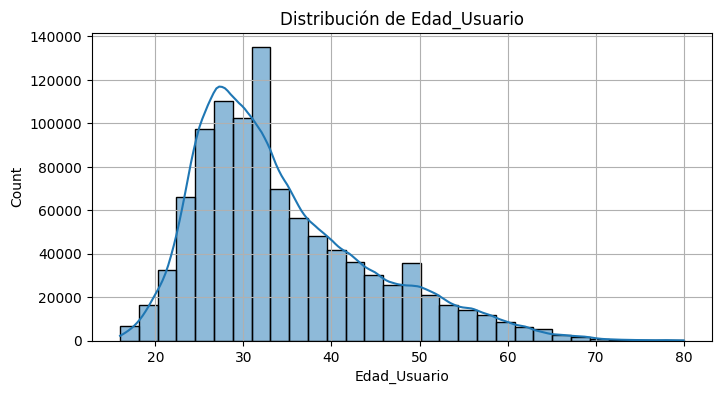

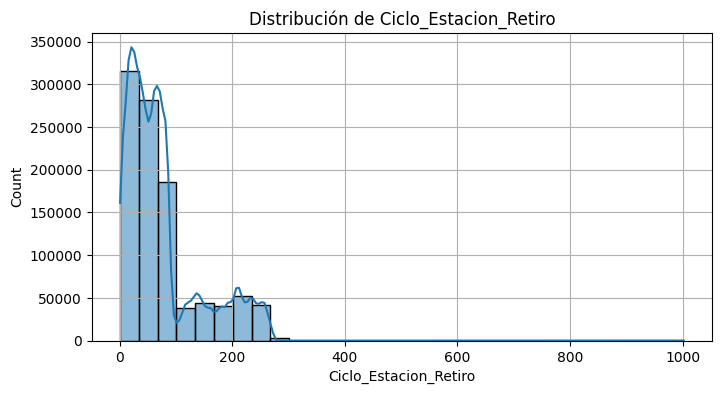

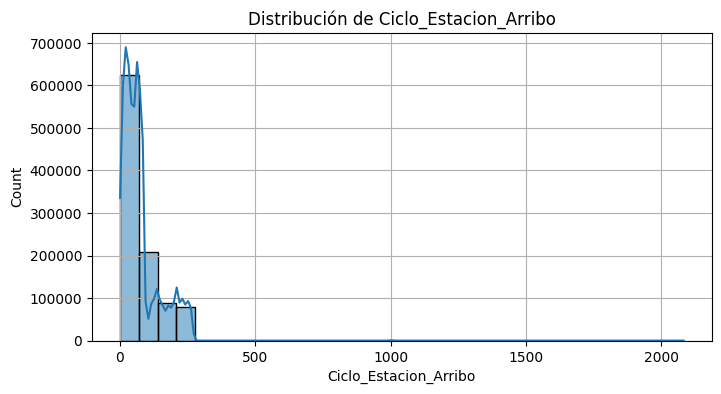

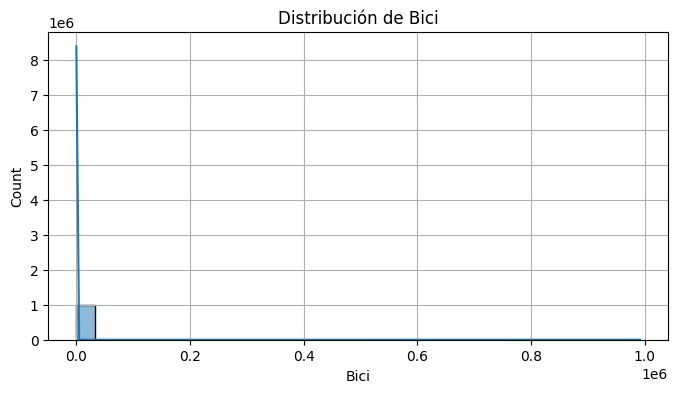

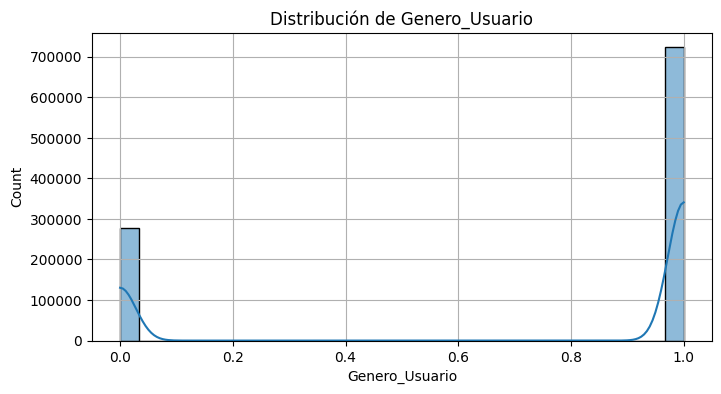

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in tad.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(tad[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.grid(True)
    plt.show()

Ajustes finales a la TAD

In [8]:
# Eliminamos la columna de bici
tad = tad.drop(columns=['Bici'])

# Normalizamos las variables numéricas
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(tad)

In [10]:
umbral = 500

retiros_extremos = tad[tad['Ciclo_Estacion_Retiro'] > umbral]
print(f"Estaciones de RETIRO > {umbral}: {len(retiros_extremos):,} registros")

arribos_extremos = tad[tad['Ciclo_Estacion_Arribo'] > umbral]
print(f"Estaciones de ARRIBO > {umbral}: {len(arribos_extremos):,} registros")

print("\nTOP valores de RETIRO:")
print(retiros_extremos['Ciclo_Estacion_Retiro'].value_counts().sort_index().tail(10))

print("\nTOP valores de ARRIBO:")
print(arribos_extremos['Ciclo_Estacion_Arribo'].value_counts().sort_index().tail(10))

Estaciones de RETIRO > 500: 16 registros
Estaciones de ARRIBO > 500: 176 registros

TOP valores de RETIRO:
Ciclo_Estacion_Retiro
1001    8
1002    8
Name: count, dtype: int64

TOP valores de ARRIBO:
Ciclo_Estacion_Arribo
1000     3
1001    94
1002    77
2081     1
2083     1
Name: count, dtype: int64


In [11]:
tad_filtrada = tad[
    (tad['Ciclo_Estacion_Retiro'] <= 500) &
    (tad['Ciclo_Estacion_Arribo'] <= 500)
].copy()

print(f"Registros finales para clustering: {len(tad_filtrada):,}")

Registros finales para clustering: 999,815


In [12]:
from sklearn.preprocessing import StandardScaler

# Normalización
scaler = StandardScaler()
X = scaler.fit_transform(tad_filtrada)

K-Means

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

tad_filtrada['Cluster_KMeans'] = clusters

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


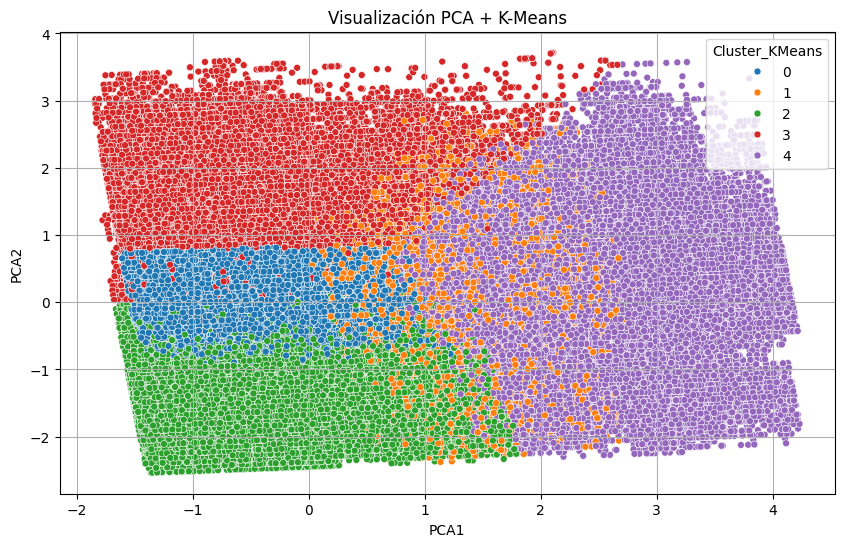

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

tad_filtrada['PCA1'] = X_pca[:, 0]
tad_filtrada['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=tad_filtrada, x='PCA1', y='PCA2', hue='Cluster_KMeans', palette='tab10', s=25)
plt.title("Visualización PCA + K-Means")
plt.grid(True)
plt.show()

Gaussian Mixture Models (GMM)

In [15]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
clusters_gmm = gmm.fit_predict(X)

tad_filtrada['Cluster_GMM'] = clusters_gmm

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


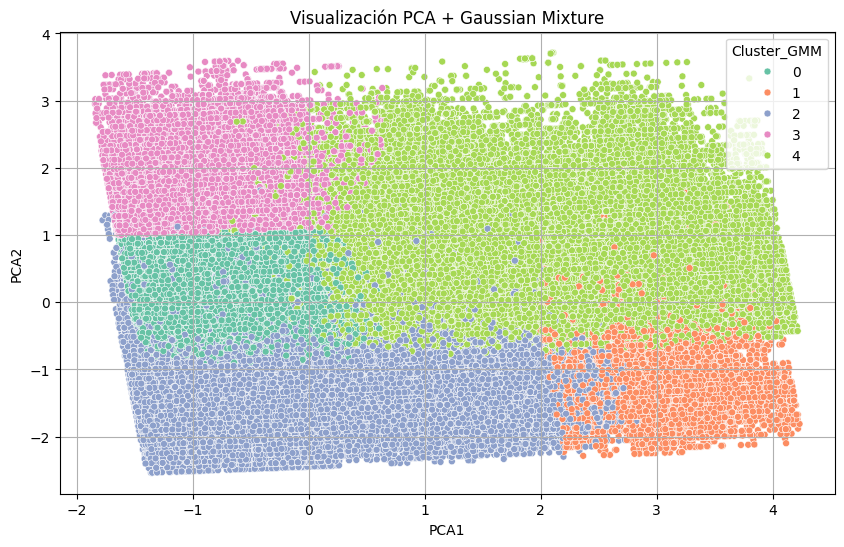

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=tad_filtrada, x='PCA1', y='PCA2', hue='Cluster_GMM', palette='Set2', s=25)
plt.title("Visualización PCA + Gaussian Mixture")
plt.grid(True)
plt.show()

Comparación K-Means y Gaussiano

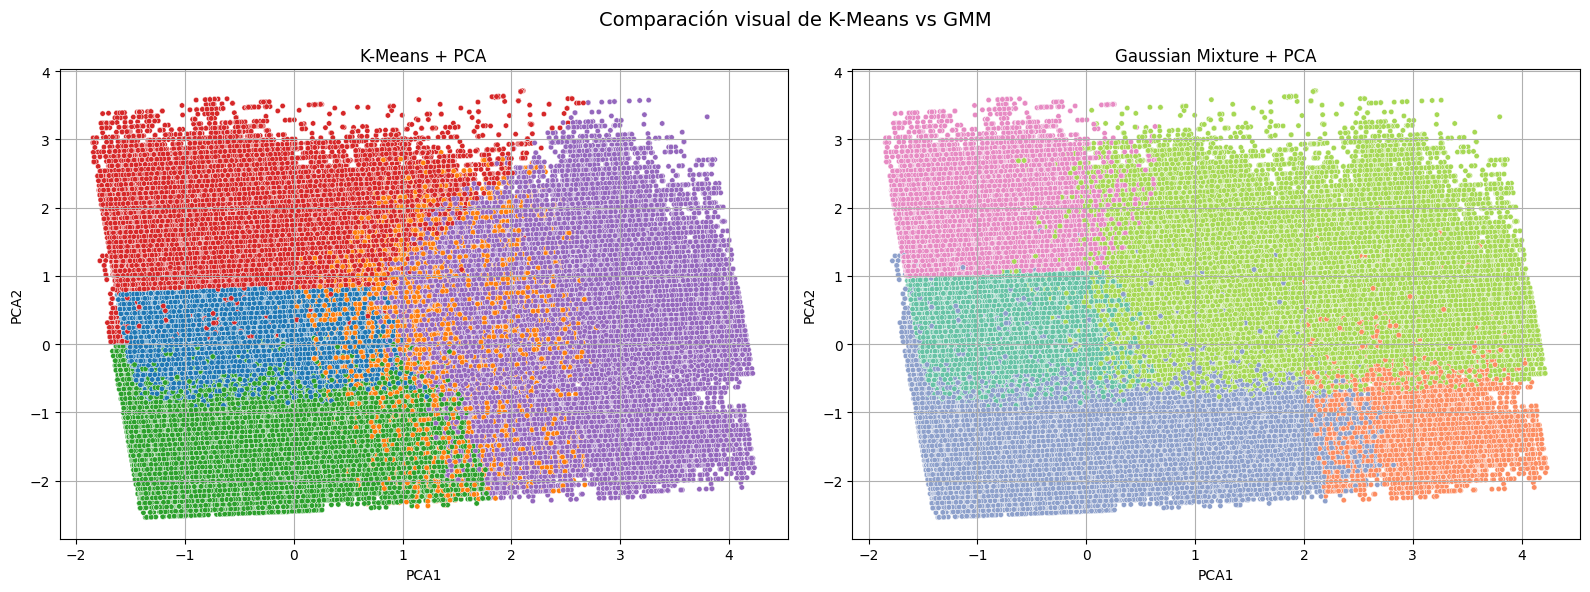

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
sns.scatterplot(
    data=tad_filtrada, x='PCA1', y='PCA2', hue='Cluster_KMeans',
    palette='tab10', s=15, ax=axs[0], legend=False
)
axs[0].set_title("K-Means + PCA")
axs[0].grid(True)

# GMM
sns.scatterplot(
    data=tad_filtrada, x='PCA1', y='PCA2', hue='Cluster_GMM',
    palette='Set2', s=15, ax=axs[1], legend=False
)
axs[1].set_title("Gaussian Mixture + PCA")
axs[1].grid(True)

plt.suptitle("Comparación visual de K-Means vs GMM", fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
print("Tamaño de clústeres - KMeans:")
print(tad_filtrada['Cluster_KMeans'].value_counts().sort_index())

print("\nTamaño de clústeres - GMM:")
print(tad_filtrada['Cluster_GMM'].value_counts().sort_index())

Tamaño de clústeres - KMeans:
Cluster_KMeans
0    404267
1     54973
2    223202
3    170387
4    146986
Name: count, dtype: int64

Tamaño de clústeres - GMM:
Cluster_GMM
0    408438
1     22736
2    253842
3    105344
4    209455
Name: count, dtype: int64


Perfilamiento K-means

In [21]:
perfil_kmeans = tad_filtrada.groupby('Cluster_KMeans').agg({
    'Edad_Usuario': ['mean', 'std'],
    'Genero_Usuario': lambda x: f"{round((x==1).mean()*100, 1)}% hombres, {round((x==0).mean()*100, 1)}% mujeres",
    'Ciclo_Estacion_Retiro': ['nunique', lambda x: x.value_counts().index[0]],
    'Ciclo_Estacion_Arribo': lambda x: x.value_counts().index[0]
})

In [22]:
perfil_kmeans.columns = [
    'Edad_prom', 'Edad_std', 'Distrib_Genero',
    'Estaciones_retiro_distintas', 'Estacion_retiro_mas_usada',
    'Estacion_arribo_mas_usada'
]
perfil_kmeans.reset_index(inplace=True)
perfil_kmeans

,Cluster_KMeans,Edad_prom,Edad_std,Distrib_Genero,Estaciones_retiro_distintas,Estacion_retiro_mas_usada,Estacion_arribo_mas_usada
0,0,30.014164,5.238993,"100.0% hombres, 0.0% mujeres",136,27,27
1,1,32.665672,8.067257,"82.7% hombres, 17.3% mujeres",147,261,27
2,2,31.589000,7.521089,"0.0% hombres, 100.0% mujeres",184,36,64
3,3,50.208185,7.261769,"93.5% hombres, 6.5% mujeres",247,1,64
4,4,33.234716,9.064424,"77.7% hombres, 22.3% mujeres",268,208,208


Perfilamiento usando GMM

In [24]:
perfil_gmm = tad_filtrada.groupby('Cluster_GMM').agg({
    'Edad_Usuario': ['mean', 'std'],
    'Genero_Usuario': lambda x: f"{round((x==1).mean()*100, 1)}% hombres, {round((x==0).mean()*100, 1)}% mujeres",
    'Ciclo_Estacion_Retiro': ['nunique', lambda x: x.value_counts().index[0]],
    'Ciclo_Estacion_Arribo': lambda x: x.value_counts().index[0]
})

perfil_gmm.columns = [
    'Edad_prom', 'Edad_std', 'Distrib_Genero',
    'Estaciones_retiro_distintas', 'Estacion_retiro_mas_usada',
    'Estacion_arribo_mas_usada'
]
perfil_gmm.reset_index()
perfil_gmm

,Edad_prom,Edad_std,Distrib_Genero,Estaciones_retiro_distintas,Estacion_retiro_mas_usada,Estacion_arribo_mas_usada
Cluster_GMM,,,,,,
0,31.027632,5.992034,"100.0% hombres, 0.0% mujeres",116,27,27
1,32.804671,9.362691,"0.0% hombres, 100.0% mujeres",119,213,217
2,32.794648,9.209577,"0.0% hombres, 100.0% mujeres",268,36,64
3,51.995396,6.343802,"100.0% hombres, 0.0% mujeres",127,41,1
4,34.371493,9.880309,"100.0% hombres, 0.0% mujeres",268,208,208


GMM separó claramente por género (K-Means mezcló más).

Mayor precisión en grupos homogéneos.

Detectó mejor los grupos femeninos, dándoles clústeres propios.

Perfilamiento

In [31]:
import glob

archivos = glob.glob("/content/drive/MyDrive/Practica4/*.csv")
muestra_con_fechas = []
chunk_size = 100_000

for file in archivos[:10]:
    for chunk in pd.read_csv(
        file,
        chunksize=chunk_size,
        on_bad_lines='skip',
        low_memory=False,
        parse_dates=['Fecha_Retiro']
    ):
        muestra_parcial = chunk.sample(frac=0.01, random_state=random.randint(0, 1000))
        muestra_con_fechas.append(muestra_parcial)

        if sum(len(x) for x in muestra_con_fechas) >= 100_000:
            break

df_fechas = pd.concat(muestra_con_fechas).reset_index(drop=True)
print(f"Muestra con fechas creada: {len(df_fechas):,} registros")


Muestra con fechas creada: 8,401 registros


In [37]:
from sklearn.preprocessing import StandardScaler

df_temporal = df_fechas[['Edad_Usuario', 'Ciclo_Estacion_Retiro', 'Ciclo_Estacion_Arribo', 'Genero_Usuario']].dropna()

df_temporal['Genero_Usuario'] = df_temporal['Genero_Usuario'].map({'F': 0, 'M': 1}).astype('Int64')

scaler = StandardScaler()
X_temp = scaler.fit_transform(df_temporal)

In [38]:
from sklearn.mixture import GaussianMixture

gmm_temp = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
df_temporal['Cluster_GMM'] = gmm_temp.fit_predict(X_temp)

In [39]:
df_temporal['AñoMes'] = df_fechas.loc[df_temporal.index, 'Fecha_Retiro'].dt.to_period('M').astype(str)

perfil_temporal = df_temporal.groupby(['AñoMes', 'Cluster_GMM']).size().reset_index(name='Viajes')

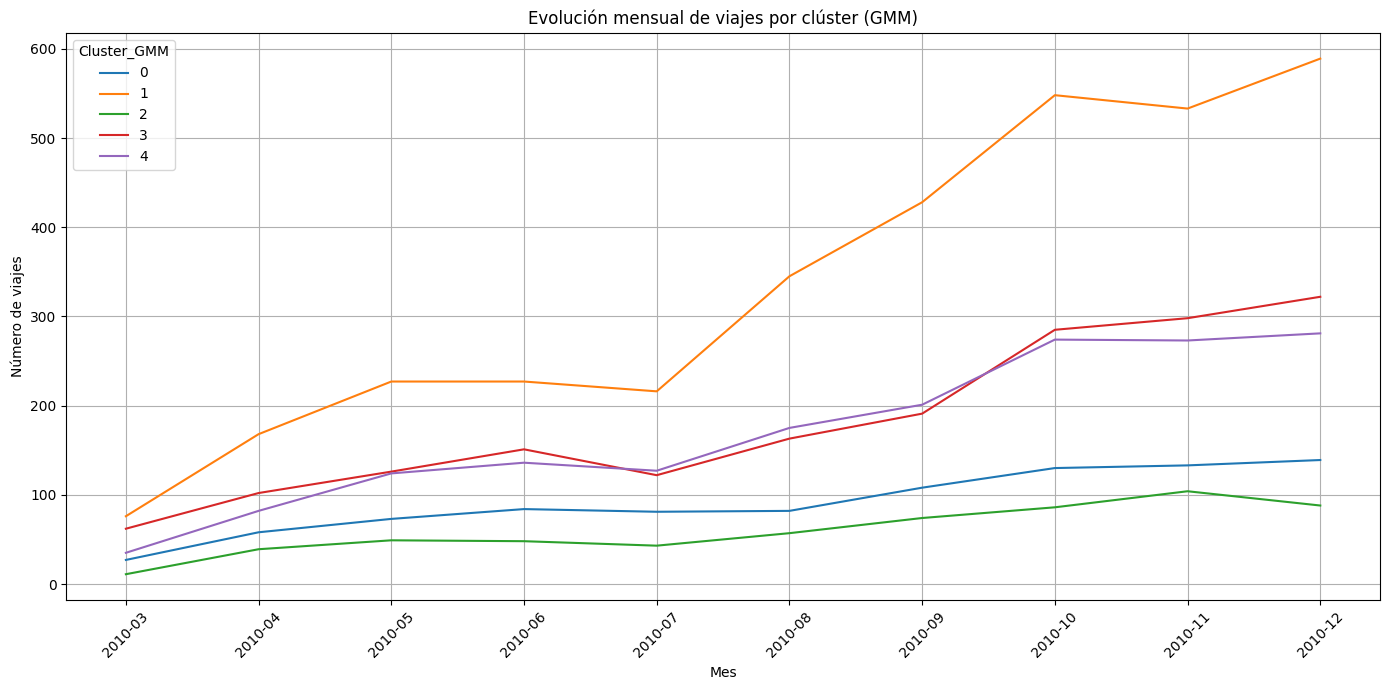

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
sns.lineplot(data=perfil_temporal, x='AñoMes', y='Viajes', hue='Cluster_GMM', palette='tab10')
plt.xticks(rotation=45)
plt.title('Evolución mensual de viajes por clúster (GMM)')
plt.xlabel('Mes')
plt.ylabel('Número de viajes')
plt.grid(True)
plt.tight_layout()
plt.show()